In [21]:

import numpy as np
import matplotlib.pyplot as plt
%config InLineBackend.figure_format = 'svg'

import matplotlib
from matplotlib import animation, rc
from IPython.display import HTML

import IPython.display as ipd

import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp
from schemdraw import flow

# some help from:
# http://louistiao.me/posts/notebooks/embedding-matplotlib-animations-in-jupyter-as-interactive-javascript-widgets/



 

# Introducing Losses

Real strings, however, introduce losses when reflecting the waves at either end.
These losses are caused be the coupling between string and body, as well as the resonant behavior of the body itself. Thus, they contribute significantly to the individual sound of an instrument.
In physical modeling, these losses can be implemented by inserting filters between the delay lines:



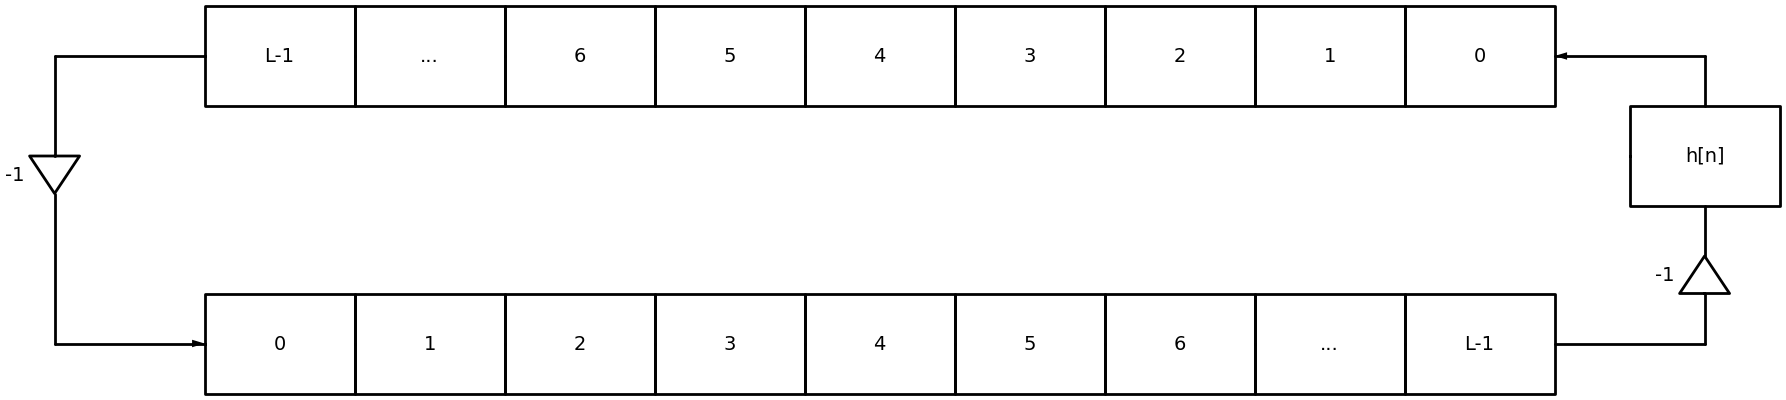

In [22]:
with schem.Drawing() as d:

    d.push()
    d.add(e.Line().right())
    
    d.add(dsp.Box().label('L-1'))
    d.add(dsp.Box().label('...'))
    d.add(dsp.Box().label('6'))
    d.add(dsp.Box().label('5'))
    d.add(dsp.Box().label('4'))
    d.add(dsp.Box().label('3'))
    d.add(dsp.Box().label('2'))
    d.add(dsp.Box().label('1'))
    d.add(dsp.Box().label('0'))
    
    d.pop()
    
    d.add(e.Line().length(2).down())
    d.add(dsp.Amp().label('-1'))
    d.add(e.Line().length(3).down())
    d.add(e.Line().right())
    d.add(e.Arrowhead())
    
    d.add(dsp.Box().label('0'))
    d.add(dsp.Box().label('1'))
    d.add(dsp.Box().label('2'))
    d.add(dsp.Box().label('3'))
    d.add(dsp.Box().label('4'))
    d.add(dsp.Box().label('5'))
    d.add(dsp.Box().label('6'))
    d.add(dsp.Box().label('...'))
    d.add(dsp.Box().label('L-1'))
    
    #d.add(e.ARROWHEAD,label='$y[n]$')
    
    d.add(e.Line().right())
    d.add(e.Line().length(1).up())
    d.add(dsp.Amp().label('-1'))
    d.add(e.Line().length(1).up()) 
    d.add(dsp.Box().label('h[n]'))
    d.add(e.Line().length(1).up()) 
    d.add(e.Line().left())
    d.add(e.Arrowhead())
    
    d.draw();


In [23]:
###################################################################
# function for plucking the string

def pluck(L,P):
    
    x_L = np.zeros(L);
    x_R = np.zeros(L);
    
    x_L[0:P] = np.linspace(0,1,P)
    x_R[0:P] = np.linspace(0,1,P)
    
    x_L[P:L-1] = np.linspace(1,0,L-P-1)
    x_R[P:L-1] = np.linspace(1,0,L-P-1)
    
    return x_L, x_R

In [24]:
# Parameters
###################################################################

fs        = 48000

# length of the delay lines:
L         = 300

# feedback gain:
g         = 0.95

# pluck position:
pluck_pos = 3

# pickup position:
pick      = 5

# filter length:
N         = 20

pick_pos  = 10

n_out     = 300

x_L, x_R  = pluck(L,20)


y    = np.array([])

# the filter is a simple moving average
filt = np.zeros(N)



-----

# Plucked String Sound

The result of the waveguide synthesis has the characteristics of a plucked string with a crisp onset and a sinusoidal decay:

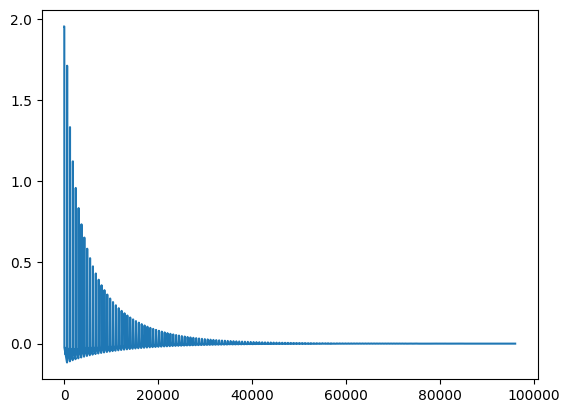

In [25]:

fs          = 48000

###################################################################
# function for plucking the string

def pluck(L,P):
    
    x_L = np.zeros(L);
    x_R = np.zeros(L);
    
    x_L[1:P] = np.linspace(0,1,P-1)
    x_R[1:P] = np.linspace(0,1,P-1)
    
    x_L[P:L-1] = np.linspace(1,0,L-P-1)
    x_R[P:L-1] = np.linspace(1,0,L-P-1)
    
    return x_L, x_R

###################################################################
# function: - get the next output sample
#           - shift all buffers

def next_step(x_L, x_R, filt, g, pick):
    
    # delay line outputs
    l_out = x_L[0]
    r_out = x_R[len(x_R)-1]    
    
    # filter output
    f_out = sum(filt)/len(filt)
    
    # shift all arrays
    x_L   = np.roll(x_L,-1)
    x_R   = np.roll(x_R,1)    
    filt  = np.roll(filt,1)    
    
    # insert output values
    x_L[len(x_L)-1] = -f_out
    x_R[0]          = -l_out * g
    filt[0]         = r_out
    
    out =  x_L[pick] + x_R[pick]
    
    return x_L, x_R, filt, out


###################################################################

# length of the delay line:
L = 300
# feedback gain:
g = 0.95
# pluck position:
pluck_pos = 3
# pickup position:
pick = 5
# filter length:
N = 20

       
    
x_L, x_R = pluck(L,pluck_pos)

y = np.array([])

# the filter is a simple moving average
filt = np.zeros(N)

for idx in range(2*fs):

    x_L, x_R, filt, out = next_step(x_L, x_R, filt, g, pick_pos)
    y = np.append(y,out)


    
    
ipd.display(ipd.Audio(y, rate=fs));
    
plt.plot(y);
    


 

-----

# Smoothing Visualization

With an additional lowpass between the waveguides, the signal will get smoother with every iteration, resulting in a crisp onset with a sinusoidal decay. 
This example works with a basic moving average filter (FIR with boxcar frequency response) with a length of $N=5$.
The slow version shows the smoothing of the excitation function for both delay lines even during the first iterations:

In [30]:


###################################################################

# length of the delay line:
L = 11
# feedback gain:
g = 0.95
# pluck position:
pluck_pos = 1
# pickup position:
pick = 5
# filter length:
N = 5

       
    
x_L, x_R = pluck(L,pluck_pos)

y = np.array([])

# the filter is a simple moving average
filt = np.zeros(N)

###################################################################

fig    = plt.figure()
fig.tight_layout(pad=3.0)

ax     = fig.add_subplot(2, 1, 1)
line,  = ax.plot(x_L,color=[0.5,0.3,0.3]);
#ax.set_title('Left-travelling Delay Line')
ax.set_xlabel("$i$");
ax.set_ylabel("$y^+$");
ax.set_ylim([-1, 1])


ax2    = fig.add_subplot(2, 1, 2)
rplot, = ax2.plot(x_R,color=[0.3,0.5,0.3]);
#ax2.set_title('Right-travelling Delay Line')
ax2.set_xlabel("$i$");
ax2.set_ylabel("$y^-$");
ax2.set_ylim([-1, 1])

plt.show

###################################################################
# function: - get the next output sample
#           - shift all buffers

def next_step(x_L, x_R, filt, g, pick):
    
    # delay line outputs
    l_out = x_L[0]
    r_out = x_R[len(x_R)-1]    
    
    # filter output
    f_out = sum(filt)/len(filt)
    
    # shift all arrays
    x_L   = np.roll(x_L,-1)
    x_R   = np.roll(x_R,1)    
    filt  = np.roll(filt,1)    
    
    # insert output values
    x_L[len(x_L)-1] = -f_out
    x_R[0]          = -l_out * g
    filt[0]         = r_out
    
    out =  x_L[pick] + x_R[pick]
    
    return x_L, x_R, filt, out


###################################################################
 

def animate(frame):
       
    global x_L
    global x_R
    global y
    global filt
    global line
    global L
    global pick_pos
    global g
    global fig 
    
    # print(y)
    # print(x_L[0:5])

    # for idx in(i):

    line.set_data(np.linspace(0, L, L), x_L)
    rplot.set_data(np.linspace(0, L, L), x_R)

    x_L, x_R, filt, out = next_step(x_L, x_R, filt, g, pick_pos)
    y = np.append(y,out)

 
    #print(len(x_L))
    return (line,)    


###################################################################

def init():
    
    global line
    
    line.set_data([], [])
    return (line,)


anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=10*L, interval=200, 
                               blit=True)  

plt.close()
HTML(anim.to_jshtml())
#HTML(anim.to_html5_video());

 